# PMX QSAR Regression (Astazeneca LogD, RDKit + Morgan)
**Walters-style notebook (annotated, reproducible, external scaffold validation, new-analogue scoring)**

- Target: **LogD** 
- Features: **RDKit 2D descriptors + Crippen (RDKit) + Morgan fingerprints**
- Validation: **External scaffold holdout** (Murcko) + **GroupKFold CV on train**
- Reporting: metrics table, parity, residuals, learning curve, y-randomisation, AD (SIM_5), permutation importance

> This notebook is inspired by the structure/flow Pat Walters uses in his regression tutorial notebooks (clean data → descriptors → baseline → model → diagnostics → predict new molecules).

## 0. Environment setup
### Recommended conda environment (VS Code / Jupyter)
Run **one** of the following in your terminal (not in the notebook):

```bash
conda create -n pmx_qsar -c conda-forge python=3.10 rdkit scikit-learn pandas numpy scipy matplotlib joblib tqdm shap
conda activate pmx_qsar
```

**Notes**
- **Crippen descriptors are included in RDKit** (`rdkit.Chem.Crippen`) → no extra install.
- Optional (only if you later want extra descriptor families):
```bash
conda install -c conda-forge mordredcommunity
```

In [1]:
import sys, platform, json, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.Chem import Descriptors
from rdkit.Chem import Crippen
from rdkit.Chem import PandasTools

from sklearn.model_selection import GroupShuffleSplit, GroupKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import learning_curve

import joblib

try:
    import shap
    SHAP_AVAILABLE = True
except Exception as e:
    SHAP_AVAILABLE = False
    print("SHAP not available:", e)

print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
try:
    import rdkit
    print("RDKit:", rdkit.__version__)
except Exception:
    pass
import sklearn
print("sklearn:", sklearn.__version__)
print("numpy:", np.__version__)
print("pandas:", pd.__version__)


Failed to patch pandas - PandasTools will have limited functionality


Python: 3.11.14
Platform: Windows-10-10.0.26200-SP0
RDKit: 2025.09.4
sklearn: 1.8.0
numpy: 2.3.5
pandas: 3.0.0


## 1. Configuration
Update `CSV_PATH` if needed. This notebook assumes:
- SMILES column exists (we autodetect common names)
- Target column is `AZ_LogD74` 
- Optional ID column exists (we autodetect common names)


In [2]:
CSV_PATH = "M:\CHEM480\PMX ML\outputs\pmx_regressor_v1\data\Plasmepsin inhibitors full dataset_Sep 2025.csv"

# Pick your LogD endpoint:
TARGET_COL = "AZ_LogD74"        # default
# TARGET_COL = "UoL_LogD_70_2"  # alternative

CAND_SMILES = ["SMILES","smiles","Structure","structure","CanonicalSMILES","canonical_smiles"]
CAND_ID = ["ID","Compound_ID","Compound","Name","Molecule","MolID"]

RANDOM_SEED = 42
TEST_SIZE = 0.20

MORGAN_RADIUS = 2
MORGAN_BITS = 2048

np.random.seed(RANDOM_SEED)


## 2. Load data + quick audit
We do a minimal but strict cleaning:
- Drop rows with missing/invalid SMILES
- Drop rows with missing target
- Parse RDKit mols; drop failures
- Show target distribution and duplicates


In [3]:
df = pd.read_csv(CSV_PATH)
print("Raw shape:", df.shape)
df.head()


Raw shape: (324, 101)


,ID,Structure,IC50(D10),IC50(D10)_StdDev,Corr. IC50(D10) by 1% Alb,Corr. IC50(D10) by 1% Alb_StdDev,Corrected pIC50(D10),Corrected pIC50(D10)_StdDev,AZ_LogD74,AZ_LogD74_StdDev,...,Corrected HLM by fu,Corrected HLM by fu_StdDev,iLLE,iLLE_StdDev,LLE,LLE_StdDev,"Pred. Vdss,u","Pred. Vdss,u_StdDev",Cal. pKa,Cal. pKa_StdDev
0,AC-2-022,C[C@H](c1ccccc1)NC[C@H]([C@H](Cc2ccc(cc2)Br)NC...,2.01,0.63,0.6637,0.2080,9.178,0.136100,2.4,0.0,...,596.3,259.40,5.7,0.4559,6.778,0.136100,209.30,0.0,8.44,0.4748
1,AC-2-030,c1ccc(cc1)C[C@@H]([C@@H](CNC2(CC2)c3ccc(cc3)F)...,304.2,3.01,91.1,0.9014,7.04,0.004297,2.5,0.0,...,537.5,197.80,4.023,0.4351,4.54,0.004297,42.56,0.0,7.761,0.6247
2,AC-2-035,CC(C)(c1ccccc1)NC[C@H]([C@H](Cc2ccccc2)NC(=O)c...,13.31,5.01,5.872,2.2100,8.231,0.163500,1.6,0.0,...,336,129.00,5.113,0.4648,6.631,0.163500,27.87,0.0,8.905,0.4487
3,AC-2-038,C[C@H](c1ccc(cc1)C(F)(F)F)NC[C@H]([C@H](Cc2ccc...,33.11,0.74,9.686,0.2165,8.014,0.009706,2.8,0.0,...,1149,514.50,4.43,0.4352,5.214,0.009706,117.30,0.0,8.106,0.5208
4,AC-2-040,C[C@H](c1ccc(cc1)F)NC[C@H]([C@H](Cc2ccccc2)NC(...,12.94,0.37,5.622,0.1607,8.25,0.012420,1.7,0.0,...,134.4,46.82,5.349,0.4353,6.55,0.012420,40.06,0.0,8.573,0.4643


In [4]:
smiles_col = next((c for c in CAND_SMILES if c in df.columns), None)
id_col = next((c for c in CAND_ID if c in df.columns), None)

if smiles_col is None:
    raise ValueError(f"Could not find SMILES column. Looked for: {CAND_SMILES}")
if TARGET_COL not in df.columns:
    raise ValueError(f"{TARGET_COL} not in CSV. Example columns: {list(df.columns)[:60]}")

print("SMILES column:", smiles_col)
print("ID column:", id_col)


SMILES column: Structure
ID column: ID


In [5]:
df = df.copy()
df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors="coerce")
df[smiles_col] = df[smiles_col].astype(str)

df = df[df[TARGET_COL].notna()].copy()
df = df[df[smiles_col].notna() & (df[smiles_col].str.len() > 0)].copy()
df.reset_index(drop=True, inplace=True)

print("After dropping missing LogD/SMILES:", df.shape)
if id_col is not None:
    print("Duplicate IDs:", int(df[id_col].duplicated().sum()))
print("Duplicate SMILES:", int(df[smiles_col].duplicated().sum()))


After dropping missing LogD/SMILES: (247, 101)
Duplicate IDs: 0
Duplicate SMILES: 0


In [6]:
df["Mol"] = df[smiles_col].apply(lambda s: Chem.MolFromSmiles(str(s)))
bad = df["Mol"].isna().sum()
print("Bad mols:", int(bad))

df = df[df["Mol"].notna()].copy()
df.reset_index(drop=True, inplace=True)
print("After dropping bad mols:", df.shape)


Bad mols: 0
After dropping bad mols: (247, 102)


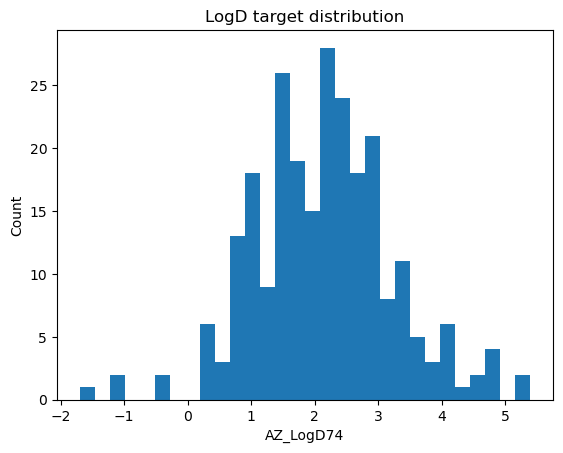

count    247.000000
mean       2.148583
std        1.092913
min       -1.700000
25%        1.500000
50%        2.200000
75%        2.800000
max        5.400000
dtype: float64


In [7]:
y_all = df[TARGET_COL].astype(float).values

plt.figure()
plt.hist(y_all, bins=30)
plt.xlabel(TARGET_COL)
plt.ylabel("Count")
plt.title("LogD target distribution")
plt.show()

print(pd.Series(y_all).describe())


## 3. Feature generation (RDKit descriptors + Crippen + Morgan bits)
### Descriptor policy
- Use **only structure-derived features** (per your request)
- RDKit 2D descriptors (a curated subset + Crippen logP/MR)
- Morgan fingerprints as 0/1 bit vectors

We keep descriptors in a dataframe (`X_desc`) and fingerprints in a dataframe (`X_fp`), then concatenate.


In [8]:
DESC_FUNCS = {
    "MolWt": Descriptors.MolWt,
    "HeavyAtomCount": Descriptors.HeavyAtomCount,
    "NumHAcceptors": Descriptors.NumHAcceptors,
    "NumHDonors": Descriptors.NumHDonors,
    "NumRotatableBonds": Descriptors.NumRotatableBonds,
    "RingCount": Descriptors.RingCount,
    "NumAromaticRings": Descriptors.NumAromaticRings,
    "TPSA": Descriptors.TPSA,
    "FractionCSP3": Descriptors.FractionCSP3,
    "MolLogP_Crippen": Crippen.MolLogP,
    "MolMR_Crippen": Crippen.MolMR,
    "NHOHCount": Descriptors.NHOHCount,
    "NOCount": Descriptors.NOCount,
    "LabuteASA": Descriptors.LabuteASA,
}

def compute_desc(mol):
    return {k: float(fn(mol)) for k, fn in DESC_FUNCS.items()}

def compute_morgan_bits(mol, radius=2, n_bits=2048):
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)
    arr = np.zeros((n_bits,), dtype=np.uint8)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

desc_rows, fp_rows = [], []
for m in df["Mol"].tolist():
    desc_rows.append(compute_desc(m))
    fp_rows.append(compute_morgan_bits(m, radius=MORGAN_RADIUS, n_bits=MORGAN_BITS))

X_desc = pd.DataFrame(desc_rows)
X_fp = pd.DataFrame(fp_rows, columns=[f"morgan_{i}" for i in range(MORGAN_BITS)])
X = pd.concat([X_desc, X_fp], axis=1)

y = df[TARGET_COL].astype(float).values

print("X:", X.shape, "y:", y.shape)
X.head()


[13:41:16] DEPRECATION WARNING: please use MorganGenerator
[13:41:16] DEPRECATION WARNING: please use MorganGenerator
[13:41:16] DEPRECATION WARNING: please use MorganGenerator
[13:41:16] DEPRECATION WARNING: please use MorganGenerator
[13:41:16] DEPRECATION WARNING: please use MorganGenerator
[13:41:16] DEPRECATION WARNING: please use MorganGenerator
[13:41:16] DEPRECATION WARNING: please use MorganGenerator
[13:41:16] DEPRECATION WARNING: please use MorganGenerator
[13:41:16] DEPRECATION WARNING: please use MorganGenerator
[13:41:16] DEPRECATION WARNING: please use MorganGenerator
[13:41:16] DEPRECATION WARNING: please use MorganGenerator
[13:41:16] DEPRECATION WARNING: please use MorganGenerator
[13:41:16] DEPRECATION WARNING: please use MorganGenerator
[13:41:16] DEPRECATION WARNING: please use MorganGenerator
[13:41:16] DEPRECATION WARNING: please use MorganGenerator
[13:41:16] DEPRECATION WARNING: please use MorganGenerator
[13:41:16] DEPRECATION WARNING: please use MorganGenerat

X: (247, 2062) y: (247,)


,MolWt,HeavyAtomCount,NumHAcceptors,NumHDonors,NumRotatableBonds,RingCount,NumAromaticRings,TPSA,FractionCSP3,MolLogP_Crippen,...,morgan_2038,morgan_2039,morgan_2040,morgan_2041,morgan_2042,morgan_2043,morgan_2044,morgan_2045,morgan_2046,morgan_2047
0,593.566,39.0,5.0,3.0,10.0,4.0,3.0,84.91,0.354839,3.8895,...,0,0,0,0,0,0,0,0,0,1
1,531.628,39.0,5.0,3.0,10.0,5.0,3.0,90.90,0.354839,3.2790,...,0,0,0,0,0,0,0,0,0,0
2,515.654,38.0,5.0,3.0,10.0,4.0,3.0,90.90,0.354839,3.3859,...,0,0,0,0,0,0,0,0,0,0
3,569.624,41.0,5.0,3.0,10.0,4.0,3.0,90.90,0.354839,4.2306,...,0,0,0,0,0,0,0,0,0,1
4,519.617,38.0,5.0,3.0,10.0,4.0,3.0,90.90,0.333333,3.3509,...,0,0,0,0,0,0,0,0,0,1


## 4. Scaffold groups (Murcko) + external test split
We compute Murcko scaffolds and use them as **groups**.
External test is a **GroupShuffleSplit** on scaffolds, giving a realistic "new scaffold" holdout.


In [9]:
def murcko_smiles(mol):
    try:
        scaf = MurckoScaffold.GetScaffoldForMol(mol)
        return Chem.MolToSmiles(scaf, isomericSmiles=False)
    except Exception:
        return "NA"

df["Scaffold"] = df["Mol"].apply(murcko_smiles)
scaffolds = df["Scaffold"].values

print("Unique scaffolds:", len(set(scaffolds)))
df["Scaffold"].value_counts().head(10)


Unique scaffolds: 115


Scaffold
O=C(NC(CCNCc1ccccc1)Cc1ccccc1)c1ccc(C(=O)N2CCNCC2)cc1                 36
O=C(NC(CCNC1CCOCC1)Cc1ccccc1)c1ccc(C(=O)N2CCCCC2)cc1                  25
O=C(NC(CCNCc1ccccc1)Cc1ccccc1)c1ccc(C(=O)N2CCCCC2)cc1                 11
O=C(NC(CCNCc1ccccc1)Cc1ccccc1)c1ccc(C(=O)N2CCOCC2)cc1                  8
O=C(NC(CCNC1CCOCC1)Cc1ccccc1)c1ccc(C(=O)N2CCNCC2)cc1                   7
O=C(NC(CCNCc1ccccc1)Cc1ccccc1)c1ccc(CN2CCNCC2)cc1                      6
O=C(NC(CCNCc1ccccc1)Cc1ccc(C#Cc2ccccc2)cc1)c1ccc(C(=O)N2CCNCC2)cc1     5
O=C(NC(CCNCc1ccccc1)Cc1ccccc1)c1ccc(N2CCNCC2=O)cc1                     5
O=C(NC(CCNCc1ccccc1)Cc1ccccc1)c1ccccc1                                 5
O=C(NC(CCNCc1ccccc1)Cc1ccccc1)c1ccc(C(=O)N2CC3(CNC3)C2)cc1             5
Name: count, dtype: int64

In [10]:
gss = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_SEED)
idx = np.arange(len(df))
train_idx, test_idx = next(gss.split(idx, groups=scaffolds))

X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
y_train, y_test = y[train_idx], y[test_idx]
scaf_train = scaffolds[train_idx]

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Train scaffolds:", len(set(scaf_train)), "Test scaffolds:", len(set(scaffolds[test_idx])))


Train: (211, 2062) Test: (36, 2062)
Train scaffolds: 92 Test scaffolds: 23


## 5. Baselines (Walters-style sanity checks)
We compare:
1) **DummyRegressor** (predict mean)
2) **Ridge** on descriptors only (no fingerprints)
3) **RandomForest** on descriptors+fingerprints (main model)

We evaluate on the **external scaffold test**.


In [11]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def spearman_r(y_true, y_pred):
    return float(pd.Series(y_true).corr(pd.Series(y_pred), method="spearman"))

def report(y_true, y_pred, label):
    return {
        "Split": label,
        "RMSE": rmse(y_true, y_pred),
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "R2": float(r2_score(y_true, y_pred)),
        "Spearman": spearman_r(y_true, y_pred),
        "n": int(len(y_true))
    }


In [12]:
dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train, y_train)

pd.DataFrame([
    report(y_train, dummy.predict(X_train), "Train (Dummy)"),
    report(y_test, dummy.predict(X_test), "External (Dummy)")
])


c:\Users\hllpacke\.conda\envs\PMX\Lib\site-packages\pandas\core\nanops.py:1661: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
c:\Users\hllpacke\.conda\envs\PMX\Lib\site-packages\pandas\core\nanops.py:1661: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


,Split,RMSE,MAE,R2,Spearman,n
0,Train (Dummy),1.057620,0.812412,0.000000,NaN,211
1,External (Dummy),1.268946,0.986335,-0.017718,NaN,36


In [13]:
Xdesc_train = X_desc.iloc[train_idx].copy()
Xdesc_test  = X_desc.iloc[test_idx].copy()

ridge = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("var", VarianceThreshold(0.0)),
    ("model", Ridge(alpha=1.0, random_state=RANDOM_SEED))
])
ridge.fit(Xdesc_train, y_train)

pd.DataFrame([
    report(y_train, ridge.predict(Xdesc_train), "Train (Ridge, desc)"),
    report(y_test, ridge.predict(Xdesc_test), "External (Ridge, desc)")
])


,Split,RMSE,MAE,R2,Spearman,n
0,"Train (Ridge, desc)",0.505469,0.407638,0.771582,0.838667,211
1,"External (Ridge, desc)",0.719589,0.587124,0.672727,0.778115,36


## 6. Main model: RandomForest (tuned) + GroupKFold CV on train
We tune RF hyperparameters using **GroupKFold** on the training set (grouped by scaffold),
then evaluate once on the external scaffold holdout.


In [17]:
rf_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("var", VarianceThreshold(0.0)),
    ("rf", RandomForestRegressor(random_state=RANDOM_SEED, n_jobs=-1))
])

param_dist = {
    "rf__n_estimators": [600, 900, 1200, 1600],
    "rf__max_depth": [None, 10, 14, 18, 26],
    "rf__min_samples_split": [2, 5, 10],
    "rf__min_samples_leaf": [1, 2, 4, 8],
    "rf__max_features": ["sqrt", 0.2, 0.35, 0.5, 0.8],
    "rf__bootstrap": [True],
}

gkf = GroupKFold(n_splits=5)
cv_iter = list(gkf.split(X_train, y_train, groups=scaf_train))

search = RandomizedSearchCV(
    rf_pipe,
    param_distributions=param_dist,
    n_iter=40,
    scoring="neg_mean_squared_error",
    cv=cv_iter,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbose=1
)
search.fit(X_train, y_train)

best_model = search.best_estimator_
print("Best params:", search.best_params_)


Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best params: {'rf__n_estimators': 900, 'rf__min_samples_split': 2, 'rf__min_samples_leaf': 1, 'rf__max_features': 0.5, 'rf__max_depth': 18, 'rf__bootstrap': True}


In [18]:
pred_train = best_model.predict(X_train)
pred_test  = best_model.predict(X_test)

metrics_df = pd.DataFrame([
    report(y_train, pred_train, "Train (RF tuned)"),
    report(y_test, pred_test, "External (RF tuned, scaffold holdout)")
])
metrics_df


,Split,RMSE,MAE,R2,Spearman,n
0,Train (RF tuned),0.178854,0.135969,0.971402,0.984867,211
1,"External (RF tuned, scaffold holdout)",0.652863,0.543538,0.730608,0.815107,36


## 7. Model diagnostics (plots)
These are the core regression plots you should always have in a QSAR report:
- Parity plot
- Residuals vs predicted
- Residual distribution
- Absolute error vs experimental


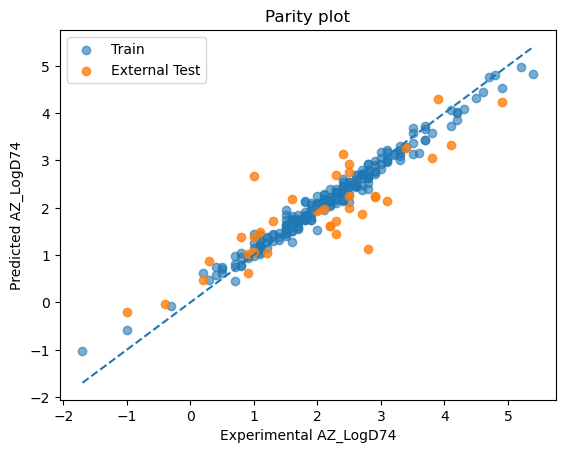

In [18]:
plt.figure()
plt.scatter(y_train, pred_train, alpha=0.6, label="Train")
plt.scatter(y_test, pred_test, alpha=0.8, label="External Test")
mn = min(np.min(y_train), np.min(y_test), np.min(pred_train), np.min(pred_test))
mx = max(np.max(y_train), np.max(y_test), np.max(pred_train), np.max(pred_test))
plt.plot([mn, mx], [mn, mx], linestyle="--")
plt.xlabel(f"Experimental {TARGET_COL}")
plt.ylabel(f"Predicted {TARGET_COL}")
plt.title("Parity plot")
plt.legend()
plt.show()


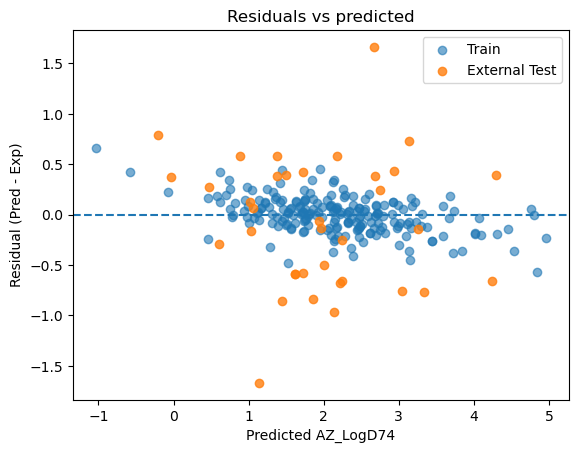

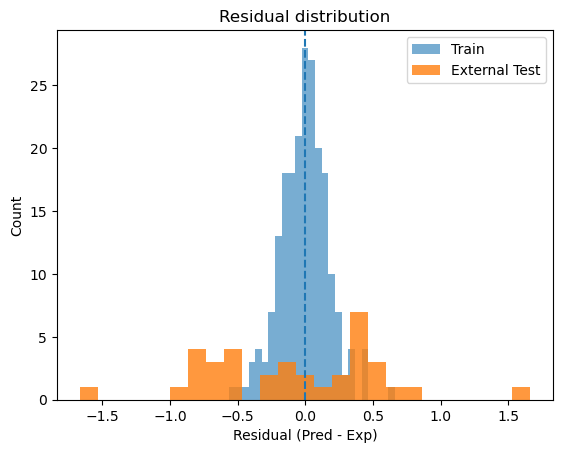

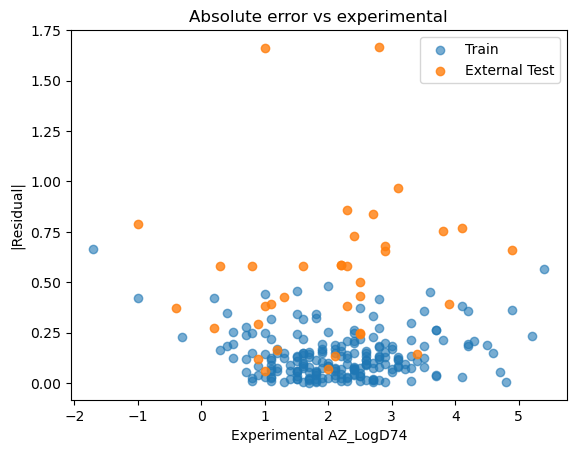

In [19]:
res_tr = pred_train - y_train
res_te = pred_test - y_test

plt.figure()
plt.scatter(pred_train, res_tr, alpha=0.6, label="Train")
plt.scatter(pred_test,  res_te, alpha=0.8, label="External Test")
plt.axhline(0, linestyle="--")
plt.xlabel(f"Predicted {TARGET_COL}")
plt.ylabel("Residual (Pred - Exp)")
plt.title("Residuals vs predicted")
plt.legend()
plt.show()

plt.figure()
plt.hist(res_tr, bins=25, alpha=0.6, label="Train")
plt.hist(res_te, bins=25, alpha=0.8, label="External Test")
plt.axvline(0, linestyle="--")
plt.xlabel("Residual (Pred - Exp)")
plt.ylabel("Count")
plt.title("Residual distribution")
plt.legend()
plt.show()

plt.figure()
plt.scatter(y_train, np.abs(res_tr), alpha=0.6, label="Train")
plt.scatter(y_test,  np.abs(res_te), alpha=0.8, label="External Test")
plt.xlabel(f"Experimental {TARGET_COL}")
plt.ylabel("|Residual|")
plt.title("Absolute error vs experimental")
plt.legend()
plt.show()


## 8. Learning curve (is the dataset limiting?)
Walters often uses simple plots that help interpret *why performance is what it is*.
Learning curves show whether more data would likely help.


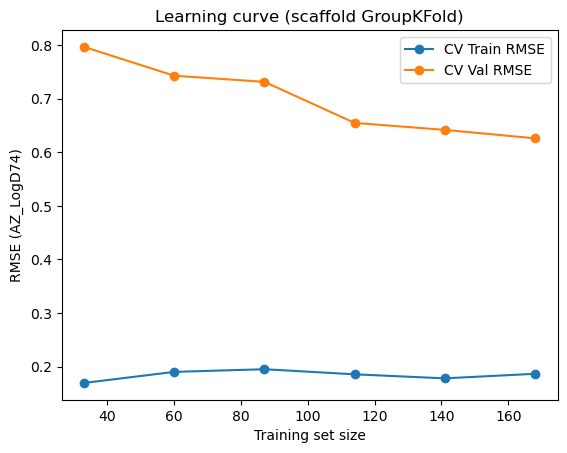

In [20]:
train_sizes, train_scores, test_scores = learning_curve(
    best_model, X_train, y_train,
    cv=cv_iter,
    scoring="neg_mean_squared_error",
    train_sizes=np.linspace(0.2, 1.0, 6),
    n_jobs=-1
)

train_rmse = np.sqrt(-train_scores.mean(axis=1))
test_rmse  = np.sqrt(-test_scores.mean(axis=1))

plt.figure()
plt.plot(train_sizes, train_rmse, marker="o", label="CV Train RMSE")
plt.plot(train_sizes, test_rmse, marker="o", label="CV Val RMSE")
plt.xlabel("Training set size")
plt.ylabel(f"RMSE ({TARGET_COL})")
plt.title("Learning curve (scaffold GroupKFold)")
plt.legend()
plt.show()


## 9. Feature importance (Permutation importance on external)
Permutation importance is generally more reliable than RF impurity importance.


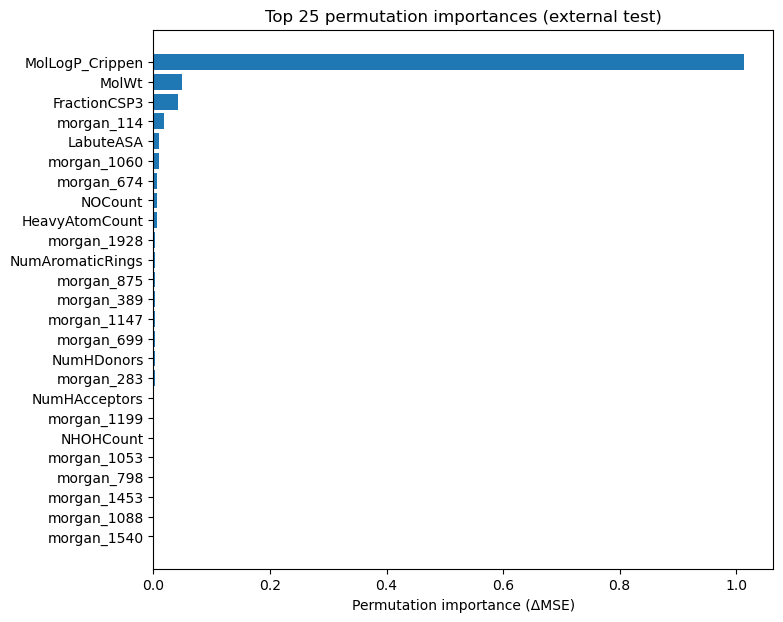

,feature,perm_mean,perm_std
9,MolLogP_Crippen,1.013015,0.186342
0,MolWt,0.049707,0.020674
8,FractionCSP3,0.042764,0.031197
128,morgan_114,0.018468,0.008646
13,LabuteASA,0.009910,0.016109
1074,morgan_1060,0.009407,0.005134
688,morgan_674,0.006216,0.003845
12,NOCount,0.005835,0.005667
1,HeavyAtomCount,0.005641,0.007784
1942,morgan_1928,0.003517,0.002357


In [21]:
perm = permutation_importance(
    best_model, X_test, y_test,
    scoring="neg_mean_squared_error",
    n_repeats=10,
    random_state=RANDOM_SEED,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    "feature": X_test.columns,
    "perm_mean": perm.importances_mean,
    "perm_std": perm.importances_std
}).sort_values("perm_mean", ascending=False)

top = perm_df.head(25).iloc[::-1]
plt.figure(figsize=(8,7))
plt.barh(top["feature"], top["perm_mean"])
plt.xlabel("Permutation importance (ΔMSE)")
plt.title("Top 25 permutation importances (external test)")
plt.show()

perm_df.head(10)


## 10. SHAP (safe mode)
Full SHAP on 2000+ Morgan bits can be heavy.
We follow a pragmatic approach:
- take **top-K features** by permutation importance
- fit a small explain model
- compute SHAP on a sample


C:\Users\hllpacke\AppData\Local\Temp\ipykernel_31400\3328868195.py:24: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, Xt[:n_shap], plot_type="bar", show=True)


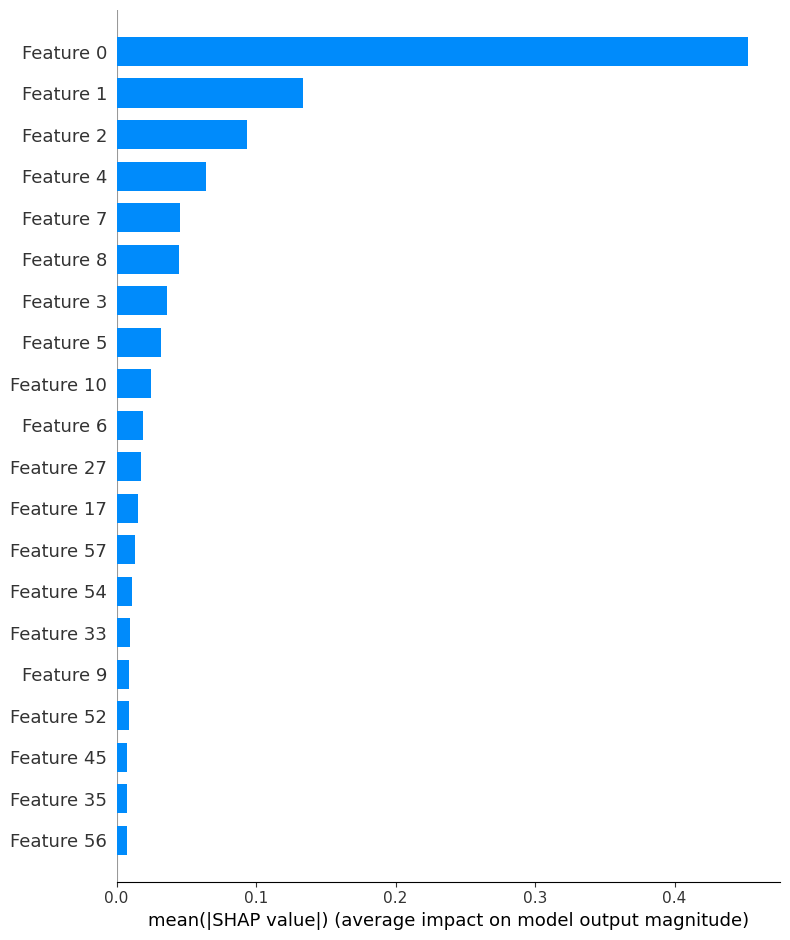

In [22]:
if not SHAP_AVAILABLE:
    print("Install SHAP: conda install -c conda-forge shap")
else:
    TOP_K = 60
    top_features = perm_df["feature"].head(TOP_K).tolist()
    Xtr_k = X_train[top_features].copy()

    rf_params = {k.replace("rf__", ""): v for k, v in search.best_params_.items()}
    explain_model = Pipeline([
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
        ("var", VarianceThreshold(0.0)),
        ("rf", RandomForestRegressor(random_state=RANDOM_SEED, n_jobs=-1, **rf_params))
    ])
    explain_model.fit(Xtr_k, y_train)

    Xt = explain_model.named_steps["imputer"].transform(Xtr_k)
    Xt = explain_model.named_steps["var"].transform(Xt)

    rf_k = explain_model.named_steps["rf"]
    explainer = shap.TreeExplainer(rf_k)

    n_shap = min(250, Xt.shape[0])
    sv = explainer.shap_values(Xt[:n_shap])
    shap.summary_plot(sv, Xt[:n_shap], plot_type="bar", show=True)


## 11. Y-randomisation (chance correlation check)
We train the same model multiple times with shuffled y and see how often we beat the real model.
We report an **empirical p-value** and a **z-score**.


{'R2_real': 0.7306079734554052, 'R2_rand_mean': -0.10776555908472009, 'R2_rand_std': 0.2097422963855529, 'z': 3.9971600720677314, 'empirical_p': 0.0}


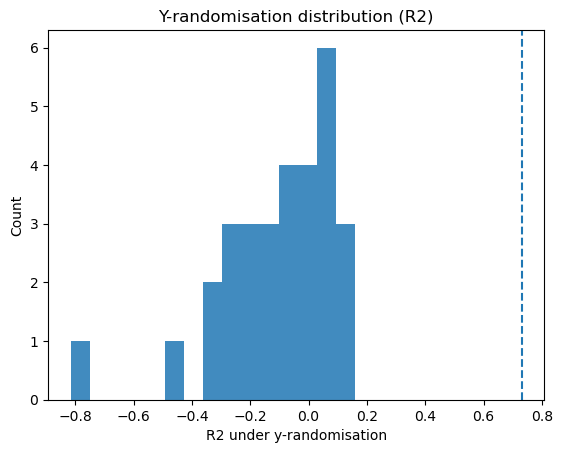

In [23]:
def y_randomisation_r2(n_perm=30, seed=42):
    rng = np.random.default_rng(seed)
    rf_params = {k.replace("rf__", ""): v for k, v in search.best_params_.items()}
    r2s = []
    for _ in range(n_perm):
        y_shuf = rng.permutation(y_train)
        m = Pipeline([
            ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
            ("var", VarianceThreshold(0.0)),
            ("rf", RandomForestRegressor(random_state=seed, n_jobs=-1, **rf_params))
        ])
        m.fit(X_train, y_shuf)
        p = m.predict(X_test)
        r2s.append(r2_score(y_test, p))
    return np.array(r2s, float)

r2_rand = y_randomisation_r2(n_perm=30, seed=RANDOM_SEED)
r2_real = float(r2_score(y_test, pred_test))

mu, sd = float(np.mean(r2_rand)), float(np.std(r2_rand, ddof=1))
z = (r2_real - mu) / (sd + 1e-12)
p_emp = float(np.mean(r2_rand >= r2_real))

print({"R2_real": r2_real, "R2_rand_mean": mu, "R2_rand_std": sd, "z": float(z), "empirical_p": p_emp})

plt.figure()
plt.hist(r2_rand, bins=15, alpha=0.85)
plt.axvline(r2_real, linestyle="--")
plt.xlabel("R2 under y-randomisation")
plt.ylabel("Count")
plt.title("Y-randomisation distribution (R2)")
plt.show()


## 12. Applicability domain (SIM_5 to training)
Compute mean similarity to the 5 nearest training neighbours.
Low SIM_5 suggests extrapolation.


[13:07:02] DEPRECATION WARNING: please use MorganGenerator
[13:07:02] DEPRECATION WARNING: please use MorganGenerator
[13:07:02] DEPRECATION WARNING: please use MorganGenerator
[13:07:02] DEPRECATION WARNING: please use MorganGenerator
[13:07:02] DEPRECATION WARNING: please use MorganGenerator
[13:07:02] DEPRECATION WARNING: please use MorganGenerator
[13:07:02] DEPRECATION WARNING: please use MorganGenerator
[13:07:02] DEPRECATION WARNING: please use MorganGenerator
[13:07:02] DEPRECATION WARNING: please use MorganGenerator
[13:07:02] DEPRECATION WARNING: please use MorganGenerator
[13:07:02] DEPRECATION WARNING: please use MorganGenerator
[13:07:02] DEPRECATION WARNING: please use MorganGenerator
[13:07:02] DEPRECATION WARNING: please use MorganGenerator
[13:07:02] DEPRECATION WARNING: please use MorganGenerator
[13:07:02] DEPRECATION WARNING: please use MorganGenerator
[13:07:02] DEPRECATION WARNING: please use MorganGenerator
[13:07:02] DEPRECATION WARNING: please use MorganGenerat

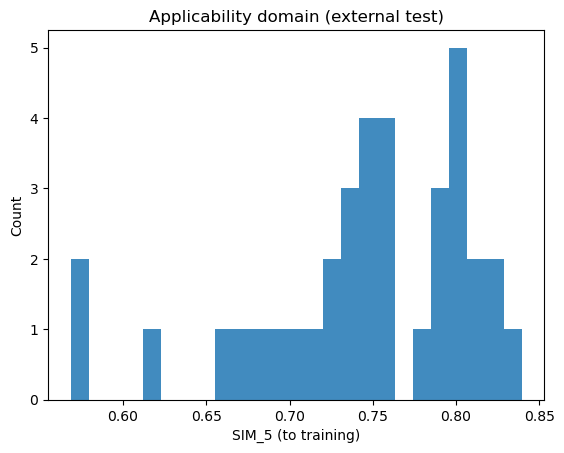

SIM_5 test mean: 0.7454041529284062


In [24]:
def morgan_fp_from_smiles(smi, radius=2, nbits=2048):
    m = Chem.MolFromSmiles(str(smi))
    if m is None:
        return None
    return AllChem.GetMorganFingerprintAsBitVect(m, radius, nBits=nbits)

def sim5_to_training(smiles_query, smiles_train, radius=2, nbits=2048, k=5):
    fps_train = [morgan_fp_from_smiles(s, radius, nbits) for s in smiles_train]
    fps_train = [fp for fp in fps_train if fp is not None]
    out = []
    for s in smiles_query:
        fpq = morgan_fp_from_smiles(s, radius, nbits)
        if fpq is None or len(fps_train) == 0:
            out.append(np.nan); continue
        sims = DataStructs.BulkTanimotoSimilarity(fpq, fps_train)
        sims_sorted = np.sort(np.array(sims))[::-1]
        out.append(float(np.mean(sims_sorted[:k])) if len(sims_sorted) >= k else float(np.mean(sims_sorted)))
    return np.array(out, float)

train_smiles = df.iloc[train_idx][smiles_col].astype(str).values
test_smiles  = df.iloc[test_idx][smiles_col].astype(str).values

sim5_test = sim5_to_training(test_smiles, train_smiles, radius=MORGAN_RADIUS, nbits=MORGAN_BITS, k=5)

plt.figure()
plt.hist(sim5_test[~np.isnan(sim5_test)], bins=25, alpha=0.85)
plt.xlabel("SIM_5 (to training)")
plt.ylabel("Count")
plt.title("Applicability domain (external test)")
plt.show()

print("SIM_5 test mean:", np.nanmean(sim5_test))


## 13. External validation table (2D structures + correct experimental values)
We build a table for the external test set that includes:
- 2D structure
- SMILES (+ ID if available)
- Experimental corrected pIC50 (D10)
- Predicted corrected pIC50
- Error

We also include a strict alignment assertion.


In [25]:
exp_from_df = df.iloc[test_idx][TARGET_COL].astype(float).values
assert np.allclose(exp_from_df, y_test), "Mismatch: y_test does not match df[TARGET_COL] for test_idx"
print("Alignment check: OK")


Alignment check: OK


In [26]:
ext = df.iloc[test_idx].copy()
ext["LogD_exp"] = y_test
ext["LogD_pred"] = pred_test
ext["error"] = ext["LogD_pred"] - ext["LogD_exp"]
ext["abs_error"] = np.abs(ext["error"])
ext["SIM_5"] = sim5_test

PandasTools.RenderImagesInAllDataFrames(images=True)

cols = ([id_col] if id_col is not None else []) + ["Mol", smiles_col, "Scaffold", "SIM_5", "LogD_exp", "LogD_pred", "error", "abs_error"]
ext_tbl = ext[cols].sort_values("abs_error", ascending=False)
ext_tbl.head(50)


Failed to patch pandas - unable to change molecule rendering


,ID,Mol,Structure,Scaffold,SIM_5,LogD_exp,LogD_pred,error,abs_error
108,AMPT171,<rdkit.Chem.rdchem.Mol object at 0x000001329D3...,c1cc(ccc1C(=O)N[C@@H](Cc2cc(cc(c2)F)F)[C@@H](C...,O=C(NC(CCNC1CCOCC1)Cc1ccccc1)c1ccc(C(=O)N2CCNC...,0.800699,2.8,1.132000,-1.668000,1.668000
173,AMPT248,<rdkit.Chem.rdchem.Mol object at 0x000001329D3...,C[C@H](c1ccccc1)NC[C@H]([C@H](Cc2cc(cc(c2)F)F)...,O=C(NC(CCNCc1ccccc1)Cc1ccccc1)c1ccc(C(=O)N2CCC...,0.753657,1.0,2.663844,1.663844,1.663844
51,AMPB105,<rdkit.Chem.rdchem.Mol object at 0x000001329D2...,C[C@H](C#C)NC[C@H]([C@H](Cc1cc(cc(c1)F)F)NC(=O...,O=C(NCCc1ccccc1)c1ccc(C(=O)N2CCCCC2)cc1,0.745511,3.1,2.131199,-0.968801,0.968801
82,AMPT138,<rdkit.Chem.rdchem.Mol object at 0x000001329D3...,CN1CCN(CC1)C(=O)c2ccc(cc2)C(=O)N[C@@H](Cc3cc(c...,O=C(NCCC(Cc1ccccc1)NC(=O)c1ccc(C(=O)N2CCNCC2)c...,0.757086,2.3,1.439830,-0.860170,0.860170
103,AMPT166,<rdkit.Chem.rdchem.Mol object at 0x000001329D3...,C[C@H](c1ccccc1)NC[C@H]([C@H](Cc2ccccc2)NC(=O)...,O=C(NC(CCNCc1ccccc1)Cc1ccccc1)c1ccc2c(N3CCNCC3...,0.669651,2.7,1.860750,-0.839250,0.839250
227,LQPI-12,<rdkit.Chem.rdchem.Mol object at 0x000001329D3...,c1ccc(cc1)C[C@@H]([C@@H](CNC2CCOCC2)O)NC(=O)c3...,O=C(NC(CCNC1CCOCC1)Cc1ccccc1)c1ccc(C(=O)N2CCNC...,0.818297,-1.0,-0.211333,0.788667,0.788667
52,AMPB107p,<rdkit.Chem.rdchem.Mol object at 0x000001329D2...,C[C@H](c1cccc(c1)C2(N=N2)C(F)(F)F)NC[C@H]([C@H...,O=C(NC(CCNCc1cccc(C2N=N2)c1)Cc1ccccc1)c1ccc(C(...,0.620746,4.1,3.331000,-0.769000,0.769000
131,AMPT202,<rdkit.Chem.rdchem.Mol object at 0x000001329D3...,CC(C)(C)C1CCN(CC1)C(=O)c2ccc(cc2)C(=O)N[C@@H](...,O=C(NC(CCNC1CCCC1)Cc1ccccc1)c1ccc(C(=O)N2CCCCC...,0.763019,3.8,3.046000,-0.754000,0.754000
56,AMPC106,<rdkit.Chem.rdchem.Mol object at 0x000001329D2...,C[C@H](c1ccccc1)NC[C@H]([C@H](Cc2ccc(cc2)c3cnc...,O=C(NC(CCNCc1ccccc1)Cc1ccc(-c2cncnc2)cc1)c1ccc...,0.781786,2.4,3.130650,0.730650,0.730650
25,AC-2-134,<rdkit.Chem.rdchem.Mol object at 0x000001329D2...,C[C@H](c1ccccc1)NC[C@H]([C@H](Cc2cc(cc(c2)F)F)...,O=C(NC(CCNCc1ccccc1)Cc1ccccc1)c1ccc(C(=O)N2CCN...,0.810728,2.9,2.221647,-0.678353,0.678353


## 14. Save the trained model
We save the pipeline (`best_model`) so you can reuse it later without retraining.


In [27]:
MODEL_OUT = f"pmx_logd_rf_rdkit_morgan_{TARGET_COL}.joblib"
joblib.dump(best_model, MODEL_OUT)
print("Saved:", MODEL_OUT)


Saved: pmx_logd_rf_rdkit_morgan_AZ_LogD74.joblib


## 15. Score new designed analogues (P2 bioisosteres)
### Workflow
1) Create a CSV of your new analogues with columns:
- `ID` (optional)
- `SMILES` (or `Structure`)
2) Set `NEW_CSV_PATH`
3) Run the cells below to get:
- predicted LogD
- 2D structures
- motif flags (quinoline / isoquinoline / quinazoline)
- top predicted (potent) vs bottom predicted (low)


In [15]:
def featurize_smiles(smiles_list):
    mols, desc_rows, fp_rows, valid = [], [], [], []
    for i, s in enumerate(smiles_list):
        m = Chem.MolFromSmiles(str(s))
        if m is None:
            continue
        mols.append(m)
        desc_rows.append(compute_desc(m))
        fp_rows.append(compute_morgan_bits(m, radius=MORGAN_RADIUS, n_bits=MORGAN_BITS))
        valid.append(i)
    Xd = pd.DataFrame(desc_rows)
    Xf = pd.DataFrame(fp_rows, columns=[f"morgan_{i}" for i in range(MORGAN_BITS)])
    return pd.concat([Xd, Xf], axis=1), mols, valid


In [19]:
NEW_CSV_PATH = "PresentationAnalogues.csv"
new_df = pd.read_csv(NEW_CSV_PATH)

new_smiles_col = next((c for c in CAND_SMILES if c in new_df.columns), None)
new_id_col = next((c for c in CAND_ID if c in new_df.columns), None)
if new_smiles_col is None:
    raise ValueError(f"Need a SMILES column in new CSV. Looked for {CAND_SMILES}")

Xnew, mols, valid_idx = featurize_smiles(new_df[new_smiles_col].astype(str).tolist())

scored = new_df.iloc[valid_idx].copy()
scored["Mol"] = mols
scored["LogD_pred"] = best_model.predict(Xnew)

PandasTools.RenderImagesInAllDataFrames(images=True)
cols = ([new_id_col] if new_id_col is not None else []) + ["Mol", new_smiles_col, "LogD_pred"]
scored[cols].sort_values("LogD_pred", ascending=False).reset_index(drop=True)

[13:43:28] DEPRECATION WARNING: please use MorganGenerator
[13:43:28] DEPRECATION WARNING: please use MorganGenerator
[13:43:28] DEPRECATION WARNING: please use MorganGenerator
[13:43:28] DEPRECATION WARNING: please use MorganGenerator
[13:43:28] DEPRECATION WARNING: please use MorganGenerator
Failed to patch pandas - unable to change molecule rendering


,ID,Mol,SMILES,LogD_pred
0,Indole-methyl,<rdkit.Chem.rdchem.Mol object at 0x0000020356B...,O=C(N[C@]([C@]([H])(O)CN[C@@](C1=CC=CC=C1)(C)[...,2.538240
1,Quinoline,<rdkit.Chem.rdchem.Mol object at 0x00000203577...,O=C(N[C@]([H])([C@](CN[C@@]([H])(C1=CC=CC=C1)C...,2.525484
2,Alkyne,<rdkit.Chem.rdchem.Mol object at 0x00000203577...,O[C@H](CN[C@@H](c1ccccc1)C)[C@@H](NC(C#CC(N2CC...,0.749830
3,Morpholine-methyl2,<rdkit.Chem.rdchem.Mol object at 0x00000203577...,O[C@@H]([C@H](Cc1cc(F)cc(F)c1)NC(C2OCC(C(N3CCN...,0.355486
4,Morpholine-methyl1,<rdkit.Chem.rdchem.Mol object at 0x00000203577...,O[C@@H]([C@H](Cc1cc(F)cc(F)c1)NC(C2N(C)CC(C(N3...,0.352375


In [30]:
NEW_CSV_PATH = "Novel-Analogues.csv"
new_df = pd.read_csv(NEW_CSV_PATH)

new_smiles_col = next((c for c in CAND_SMILES if c in new_df.columns), None)
new_id_col = next((c for c in CAND_ID if c in new_df.columns), None)
if new_smiles_col is None:
    raise ValueError(f"Need a SMILES column in new CSV. Looked for {CAND_SMILES}")

Xnew, mols, valid_idx = featurize_smiles(new_df[new_smiles_col].astype(str).tolist())

scored = new_df.iloc[valid_idx].copy()
scored["Mol"] = mols
scored["LogD_pred"] = best_model.predict(Xnew)

PandasTools.RenderImagesInAllDataFrames(images=True)
cols = ([new_id_col] if new_id_col is not None else []) + ["Mol", new_smiles_col, "LogD_pred"]
scored[cols].sort_values("LogD_pred", ascending=False).reset_index(drop=True)


[13:07:44] DEPRECATION WARNING: please use MorganGenerator
[13:07:44] DEPRECATION WARNING: please use MorganGenerator
[13:07:44] DEPRECATION WARNING: please use MorganGenerator
[13:07:44] DEPRECATION WARNING: please use MorganGenerator
[13:07:44] DEPRECATION WARNING: please use MorganGenerator
[13:07:44] DEPRECATION WARNING: please use MorganGenerator
[13:07:44] DEPRECATION WARNING: please use MorganGenerator
[13:07:44] DEPRECATION WARNING: please use MorganGenerator
[13:07:44] DEPRECATION WARNING: please use MorganGenerator
[13:07:44] DEPRECATION WARNING: please use MorganGenerator
[13:07:44] DEPRECATION WARNING: please use MorganGenerator
[13:07:44] DEPRECATION WARNING: please use MorganGenerator
[13:07:44] DEPRECATION WARNING: please use MorganGenerator
[13:07:44] DEPRECATION WARNING: please use MorganGenerator
[13:07:44] DEPRECATION WARNING: please use MorganGenerator
[13:07:44] DEPRECATION WARNING: please use MorganGenerator
[13:07:44] DEPRECATION WARNING: please use MorganGenerat

,ID,Mol,Structure,LogD_pred
0,Di-orthoisopropyl-phenyl-1,<rdkit.Chem.rdchem.Mol object at 0x000001329D3...,O[C@@H]([C@H](Cc1cc(F)cc(F)c1)NC(C2=C(C(C)C)C=...,4.114222
1,Quinoline-4,<rdkit.Chem.rdchem.Mol object at 0x000001329F7...,C[C@H](NC[C@@H](O)[C@@H](Cc1cc(F)cc(F)c1)NC(=O...,2.606515
2,Isoquinoline-2,<rdkit.Chem.rdchem.Mol object at 0x000001329F7...,C[C@H](NC[C@@H](O)[C@@H](Cc1cc(F)cc(F)c1)NC(=O...,2.601182
3,Quinoline-3,<rdkit.Chem.rdchem.Mol object at 0x000001329F7...,C[C@H](NC[C@@H](O)[C@@H](Cc1cc(F)cc(F)c1)NC(=O...,2.563165
4,Quinoline-1,<rdkit.Chem.rdchem.Mol object at 0x000001329B6...,C[C@H](NC[C@@H](O)[C@@H](Cc1cc(F)cc(F)c1)NC(=O...,2.561587
5,Quinoline-9,<rdkit.Chem.rdchem.Mol object at 0x000001329F7...,C[C@H](NC[C@@H](O)[C@@H](Cc1cc(F)cc(F)c1)NC(=O...,2.526855
6,Quinoline-2,<rdkit.Chem.rdchem.Mol object at 0x000001329F7...,C[C@H](NC[C@@H](O)[C@@H](Cc1cc(F)cc(F)c1)NC(=O...,2.525484
7,Isoquinoline-1,<rdkit.Chem.rdchem.Mol object at 0x000001329F7...,C[C@H](NC[C@@H](O)[C@@H](Cc1cc(F)cc(F)c1)NC(=O...,2.518156
8,Isoquinoline-3,<rdkit.Chem.rdchem.Mol object at 0x000001329F7...,C[C@H](NC[C@@H](O)[C@@H](Cc1cc(F)cc(F)c1)NC(=O...,2.517600
9,Quinoline-5,<rdkit.Chem.rdchem.Mol object at 0x000001329F7...,C[C@H](NC[C@@H](O)[C@@H](Cc1cc(F)cc(F)c1)NC(=O...,2.496281
